# TAREA COMPUTACIONAL 1 - INVESTIGACIÓN DE OPERACIONES (ILN250)
### Planificación de la Operación y Compromiso de Unidades en un Complejo Industrial Aislado

**Profesor:** Rafael Favereau U.  
**Semestre:** Segundo Semestre 2026 (2s26)  
**Integrantes:** Cristobal Cortés, Luciano Ferroni  
**Semilla de Grupo:** **534** ($392 + 142 = 534$)  

---
Este notebook contiene la implementación computacional completa del modelo de **Unit Commitment y Despacho Económico (MILP)** utilizando **Python** y **Pyomo**, junto con el solver **HiGHS** (`appsi_highs`).

Se abordan en profundidad:
1. **Situación Inicial:**
   - **1.a)** Generación de parámetros y perfiles de instancia.
   - **1.b y 1.c)** Modelamiento del enunciado, naturaleza del problema (MILP) y resolución computacional con HiGHS.
   - **1.d)** Interpretación de resultados, orden de mérito, arranques y reserva operativa.
2. **Variaciones:**
   - **2.a)** Incorporación de un Sistema de Almacenamiento (Batería).
   - **2.b)** Respuesta de la Demanda (Carga Interrumpible y análisis de sensibilidad en $c^{shed}$).
   - **2.c)** Costo Fijo por Sobrepasar un Umbral Diario de Emisiones (Formulación Big-M y barrido de penalización $F$).
3. **Conclusiones:** Síntesis técnica, económica y regulatoria de los resultados obtenidos.


In [1]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

from generar_parametros import (
    obtener_perfil_normalizado, obtener_parametros_generadores,
    obtener_parametros_sistema, generar_datos_instancia
)
from modelo_base import construir_modelo_base, resolver_modelo, extraer_resultados
from variacion_bateria import construir_modelo_bateria, extraer_resultados_bateria
from variacion_demanda import construir_modelo_demanda, barrido_c_shed
from variacion_emisiones import construir_modelo_emisiones, barrido_F

# Configuración visual para gráficos
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#cccccc'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.autolayout'] = True
print("Librerías y módulos cargados correctamente.")


Librerías y módulos cargados correctamente.


## 1. Situación Inicial
### 1.a) Generación de Parámetros y Perfiles de Instancia

La demanda horaria $d_t$ y el precio de red $\lambda_t$ se obtuvieron mediante el generador estocástico parametrizado con la semilla 534 conforme a las expresiones:
$$d_t = \left\lfloor P^{peak} \cdot \gamma_{dia(t)} \cdot s_{h(t)} \cdot (1 + \varepsilon_t) \right\rceil$$
con $P^{peak} \sim \mathcal{N}(300, 15)$, $\gamma_{dia} = 1.0$ (días hábiles $t \le 120$) y $0.8$ (fines de semana), y $\varepsilon_t \sim \mathcal{N}(0, 0.03)$.

El precio de importación de energía eléctrica desde la red en la hora $t$ se determina por:
$$\lambda_t = \left\lfloor (100.000 + 90.000 \cdot s_{h(t)}) \cdot (1 + \eta_t) \right\rceil \text{ [CLP/MWh]}, \quad \text{con } \eta_t \sim \mathcal{N}(0, 0.05)$$

La reserva mínima requerida por seguridad ante contingencias corresponde a:
$$Res_t = \lfloor 0.10 \cdot d_t \rceil \text{ [MW]}$$


In [2]:
# Generación de datos para la Semilla Oficial de Grupo = 534
semilla_grupo = 534
datos_534 = generar_datos_instancia(semilla_grupo)
df_534 = datos_534['df']

print(f"=== ESTADÍSTICAS SEMILLA DE GRUPO {semilla_grupo} ===")
print(f"Potencia Peak generada (P_peak): {datos_534['P_peak']:.2f} MW")
print(f"Demanda horaria [MW]:")
print(f"  Mínimo:   {df_534['d_t'].min()} MW (hora t={df_534.loc[df_534['d_t'].idxmin(), 't']})")
print(f"  Máximo:   {df_534['d_t'].max()} MW (hora t={df_534.loc[df_534['d_t'].idxmax(), 't']})")
print(f"  Promedio: {df_534['d_t'].mean():.2f} MW")
print(f"  Total Semanal: {df_534['d_t'].sum()} MWh")
print(f"Precio de Red [CLP/MWh]:")
print(f"  Mínimo:   {df_534['lambda_t'].min():,d} CLP/MWh")
print(f"  Máximo:   {df_534['lambda_t'].max():,d} CLP/MWh")
print(f"  Promedio: {df_534['lambda_t'].mean():,.2f} CLP/MWh")
print(f"Reserva Operativa Requerida [MW]:")
print(f"  Mínimo:   {df_534['res_t'].min()} MW")
print(f"  Máximo:   {df_534['res_t'].max()} MW")
print(f"  Promedio: {df_534['res_t'].mean():.2f} MW")


=== ESTADÍSTICAS SEMILLA DE GRUPO 534 ===
Potencia Peak generada (P_peak): 283.23 MW
Demanda horaria [MW]:
  Mínimo:   97 MW (hora t=148)
  Máximo:   302 MW (hora t=116)
  Promedio: 202.43 MW
  Total Semanal: 34008 MWh
Precio de Red [CLP/MWh]:
  Mínimo:   128,306 CLP/MWh
  Máximo:   202,420 CLP/MWh
  Promedio: 168,787.98 CLP/MWh
Reserva Operativa Requerida [MW]:
  Mínimo:   10 MW
  Máximo:   30 MW
  Promedio: 20.24 MW


<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\cacor\AppData\Local\Temp\ipykernel_2068\2713996555.py:8: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_title(f'Perfil Semanal de Demanda Horaria $d_t$ y Precio de Red $\lambda_t$ (Semilla de Grupo {semilla_grupo})', fontweight='bold')


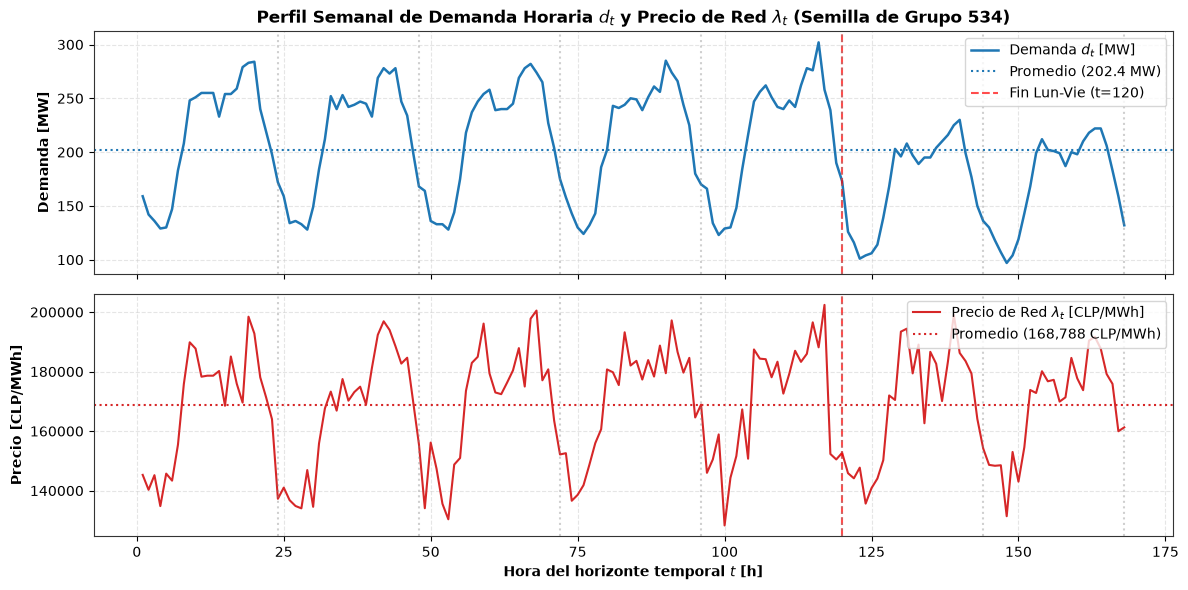

In [3]:
# Visualización de Demanda y Precios de Red para Semilla 534 (Figura 1 del informe)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(df_534['t'], df_534['d_t'], color='#1f77b4', lw=1.8, label=r'Demanda $d_t$ [MW]')
ax1.axhline(df_534['d_t'].mean(), color='#1f77b4', linestyle=':', label=f'Promedio ({df_534["d_t"].mean():.1f} MW)')
ax1.axvline(120, color='red', linestyle='--', alpha=0.7, label='Fin Lun-Vie (t=120)')
ax1.set_ylabel('Demanda [MW]', fontweight='bold')
ax1.set_title(f'Perfil Semanal de Demanda Horaria $d_t$ y Precio de Red $\lambda_t$ (Semilla de Grupo {semilla_grupo})', fontweight='bold')
ax1.grid(True)
ax1.legend(loc='upper right')

ax2.plot(df_534['t'], df_534['lambda_t'], color='#d62728', lw=1.5, label=r'Precio de Red $\lambda_t$ [CLP/MWh]')
ax2.axhline(df_534['lambda_t'].mean(), color='#d62728', linestyle=':', label=f'Promedio ({df_534["lambda_t"].mean():,.0f} CLP/MWh)')
ax2.axvline(120, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Hora del horizonte temporal $t$ [h]', fontweight='bold')
ax2.set_ylabel('Precio [CLP/MWh]', fontweight='bold')
ax2.grid(True)
ax2.legend(loc='upper right')

for d in range(1, 8):
    ax1.axvline(24 * d, color='#888888', linestyle=':', alpha=0.4)
    ax2.axvline(24 * d, color='#888888', linestyle=':', alpha=0.4)

plt.show()


### 1.b) Modelamiento del Enunciado y 1.c) Naturaleza del Problema y Solver

El problema formulado es un **Programa Lineal Entero Mixto (MILP)** puesto a que incluye variables binarias ($u_{g,t} \in \{0, 1\}$) y continuas ($p_{g,t}, g_t^{red}, v_{g,t} \ge 0$) con relaciones estrictamente lineales.

Se utilizó el solver de código abierto **HiGHS** (`appsi_highs`), ampliamente usado en investigación operativa. HiGHS resulta óptimo gracias a:
* **Pre-procesamiento Robusto (*Presolve*):** Reduce drásticamente el tamaño del modelo mediante fijación de variables y apriete de cotas.
* **Planos de Corte Especializados:** Incorpora cortes de cliques, residuo mixto entero (MIR) y Gomory, cerrando la brecha de integrabilidad en el nodo raíz.
* **Simplex Dual Multihilo y Heurísticas Primarias:** Acelera la resolución de las relajaciones en cada nodo y descubre rápidamente soluciones enteras factibles de bajo costo.

A continuación se construye y resuelve el modelo base en Pyomo para la Semilla 534.


In [4]:
# Construcción y resolución del Modelo Base para Semilla 534
m_base = construir_modelo_base(datos_534)
res_solver = resolver_modelo(m_base)
res_base = extraer_resultados(m_base, datos_534)

print(f"Estado Resolución: {res_solver.solver.termination_condition}")
print(f"Costo Total de Operación: {res_base['total_cost']:,.2f} CLP")
print(f"\nDesglose de Costos:")
print(f"  - Costo Variable:       {res_base['costos_desglosados']['variable']:16,.2f} CLP ({(res_base['costos_desglosados']['variable']/res_base['total_cost'])*100:.2f}%)")
print(f"  - Costo No-Load:        {res_base['costos_desglosados']['no_load']:16,.2f} CLP ({(res_base['costos_desglosados']['no_load']/res_base['total_cost'])*100:.2f}%)")
print(f"  - Costo de Arranque:    {res_base['costos_desglosados']['arranque']:16,.2f} CLP ({(res_base['costos_desglosados']['arranque']/res_base['total_cost'])*100:.2f}%)")
print(f"  - Importación de Red:   {res_base['costos_desglosados']['red']:16,.2f} CLP ({(res_base['costos_desglosados']['red']/res_base['total_cost'])*100:.2f}%)")


Estado Resolución: optimal
Costo Total de Operación: 1,776,019,094.00 CLP

Desglose de Costos:
  - Costo Variable:       1,664,741,000.00 CLP (93.73%)
  - Costo No-Load:          100,060,000.00 CLP (5.63%)
  - Costo de Arranque:        7,800,000.00 CLP (0.44%)
  - Importación de Red:       3,418,094.00 CLP (0.19%)


### 1.d) Interpretación de Resultados, Orden de Mérito y Reserva

El análisis técnico-económico arroja conclusiones fundamentales:
1. **Orden de Mérito Económico:** Se verifica un estricto despacho por mérito de costos variables y de no-load:
   - *Unidades de Base:* `Gas_Base_1` opera las 168 horas a plena capacidad (FP 95,9%), sin arranques. `Gas_Base_2` actúa como segunda base (FP 72,7%).
   - *Unidades Intermedias y de Punta:* `Diesel_Med_1` opera en horas laborales de alta carga (5 arranques semanales sincronizados con el inicio diurno). `Diesel_Med_2` y `Peaker` se reservan exclusivamente para los picos extremos de demanda ($FP \\le 0,5\\%$).
2. **Comportamiento de Arranques:** El modelo evita apagar unidades de gas debido a sus cuantiosos costos de partida (\$2.000.000 y \$1.800.000 CLP), mientras que aprovecha la flexibilidad de las máquinas diésel cuyos costos de arranque (\$600.000 y \$500.000 CLP) son menores.
3. **Uso Racionado de la Red Externa:** La importación de red es baja (18,0 MWh en 6 horas). Dado que su costo promedio (\$168.788 CLP/MWh) supera al generador más costoso del complejo (`Peaker` a \$120.000 CLP/MWh), la red solo se usa ante restricciones de rampa o límites de reserva en picos de demanda.
4. **Horas Críticas de Reserva Operativa:** La holgura de reserva ($\text{Reserva Disponible} - Res_t$) se vuelve más exigente en las horas de demanda punta vespertina de días hábiles ($t = 19, 43, 67, 91, 115$), correspondientes a las 18:00–20:00 horas, donde $Res_t$ alcanza 30 MW.


In [5]:
# Desglose de generación, arranques y factor de planta por unidad
print(f"=== COMPROMISO Y DESPACHO POR UNIDAD (SEMILLA {semilla_grupo}) ===")
for g, info in res_base['unidades'].items():
    print(f"{g:12s} | Gen: {info['gen_total_MWh']:8.1f} MWh | FP: {info['factor_planta']*100:5.1f}% | Horas ON: {info['horas_encendida']:3d} h | Arranques: {info['arranques']} | Emisiones: {info['emisiones_tCO2']:7.1f} tCO2")

print(f"\nImportación Red: {res_base['red']['energia_total_MWh']:.1f} MWh en {res_base['red']['horas_uso']} horas.")
tot_emiss = sum(info['emisiones_tCO2'] for info in res_base['unidades'].values())
print(f"Emisiones Totales Semanales: {tot_emiss:.1f} tCO2")


=== COMPROMISO Y DESPACHO POR UNIDAD (SEMILLA 534) ===
Gas_Base_1   | Gen:  19331.0 MWh | FP:  95.9% | Horas ON: 168 h | Arranques: 0 | Emisiones:  6765.8 tCO2
Gas_Base_2   | Gen:  12217.0 MWh | FP:  72.7% | Horas ON: 158 h | Arranques: 2 | Emisiones:  4642.5 tCO2
Diesel_Med_1 | Gen:   2378.0 MWh | FP:  23.6% | Horas ON:  69 h | Arranques: 5 | Emisiones:  1545.7 tCO2
Diesel_Med_2 | Gen:     46.0 MWh | FP:   0.5% | Horas ON:   2 h | Arranques: 2 | Emisiones:    31.3 tCO2
Peaker       | Gen:     18.0 MWh | FP:   0.3% | Horas ON:   2 h | Arranques: 1 | Emisiones:    13.5 tCO2

Importación Red: 18.0 MWh en 6 horas.
Emisiones Totales Semanales: 12998.8 tCO2


## 2. Variaciones
### 2.a) Incorporación de un Sistema de Almacenamiento

Se integró un sistema de almacenamiento con capacidad de energía $\bar{S} = 200$ MWh, potencia máxima de carga/descarga $\bar{B}^{ch} = \bar{B}^{dis} = 60$ MW, eficiencias $\eta^{ch} = \eta^{dis} = 0.95$ y estado de carga inicial y final mínimo $S_0 = 100$ MWh. Se introducen las variables $p_{ch,t}, p_{dis,t} \in [0, 60]$ y $S_t \in [0, 200]$.

**Modificaciones Matemáticas al Modelo:**
* **Balance de Carga y Condición Final:**
  $$S_t = S_{t-1} + \eta^{ch} \cdot p_{ch,t} - \frac{p_{dis,t}}{\eta^{dis}}, \quad \forall t \in T \quad (\text{con } S_0 = 100 \text{ MWh})$$
  $$S_{168} \ge S_0 = 100 \text{ MWh}$$
* **Balance de Energía Modificado para Batería:**
  $$\sum_{g \in G} p_{g,t} + g_t^{red} + p_{dis,t} = d_t + p_{ch,t}, \quad \forall t \in T$$


In [6]:
# Resolución y Análisis Variación 2.a (Batería)
m_bat = construir_modelo_bateria(datos_534)
resolver_modelo(m_bat)
res_bat = extraer_resultados_bateria(m_bat, datos_534)

ahorro = res_base['total_cost'] - res_bat['total_cost']
print(f"Costo con Batería:    {res_bat['total_cost']:,.2f} CLP")
print(f"Ahorro Económico:     {ahorro:,.2f} CLP ({ahorro/res_base['total_cost']*100:.2f}%)")
print(f"Importación Red:      {res_bat['red']['energia_total_MWh']:.1f} MWh (vs {res_base['red']['energia_total_MWh']:.1f} MWh base)")
print(f"Energía Cargada:      {res_bat['bateria']['energia_cargada_MWh']:.1f} MWh")
print(f"Energía Descargada:   {res_bat['bateria']['energia_descargada_MWh']:.1f} MWh")
print(f"Pérdidas por Ciclo:   {res_bat['bateria']['perdidas_eficiencia_MWh']:.1f} MWh")
print(f"Carga Final (S_168):  {res_bat['bateria']['soc_final_MWh']:.1f} MWh")
print(f"\nArranques con Batería vs Base:")
for g, info in res_bat['unidades'].items():
    print(f"  {g:12s}: {info['arranques']} arranques (vs {res_base['unidades'][g]['arranques']} en base)")


Costo con Batería:    1,732,045,839.34 CLP
Ahorro Económico:     43,973,254.66 CLP (2.48%)
Importación Red:      0.0 MWh (vs 18.0 MWh base)
Energía Cargada:      1225.5 MWh
Energía Descargada:   1106.0 MWh
Pérdidas por Ciclo:   119.5 MWh
Carga Final (S_168):  100.0 MWh

Arranques con Batería vs Base:
  Gas_Base_1  : 0 arranques (vs 0 en base)
  Gas_Base_2  : 1 arranques (vs 2 en base)
  Diesel_Med_1: 5 arranques (vs 5 en base)
  Diesel_Med_2: 0 arranques (vs 2 en base)
  Peaker      : 0 arranques (vs 1 en base)


**Análisis Operativo de la Batería:**
1. **Aplanamiento de Curva de Carga:** La batería almacena energía en horas de la noche-madrugada utilizando capacidad ociosa de las máquinas a gas (\$45.000 CLP/MWh) y la descarga durante los picos de las 18:00–21:00 horas inyectando hasta 60 MW.
2. **Eliminación Total de Unidades de Punta y Red Externa:** La batería elimina en un 100% la importación de red y suprime todos los arranques de `Diesel_Med_2` y `Peaker`, evitando costosos combustibles y partidas térmicas.
3. **Rentabilidad pese a las Pérdidas de Ciclo:** Aunque la eficiencia combinada ($\eta^{ch}\eta^{dis} = 90{,}25\%$) disipa 119,5 MWh semanales, el diferencial económico entre cargar a \$45.000 y evitar despachos a \$120.000 CLP/MWh genera un ahorro neto de más de \$43,9 millones CLP semanales (-2,48%).


### 2.b) Respuesta de la Demanda (Carga Interrumpible)

Se implementó la variable de recorte $r_t \ge 0$ sujeta a la cota horaria $\bar{\ell}^h = 0.20$ ($r_t \le 0.20 \cdot d_t$) y cuota semanal $\bar{\ell}^s = 0.05$ ($\sum r_t \le 0.05 \sum d_t$), con costo de corte $c^{shed}$ [CLP/MWh].

**Restricciones y cambios al modelo:**
* Balance de energía modificado: $\sum_{g \in G} p_{g,t} + g_t^{red} = d_t - r_t, \quad \forall t \in T$.
* Cotas de corte: $r_t \le 0.20 \cdot d_t \quad (\forall t \in T)$ y $\sum_{t=1}^{168} r_t \le 0.05 \cdot \sum_{t=1}^{168} d_t$.
* Función objetivo modificada: Se incorpora el término de compensación $+\sum_{t=1}^{168} c^{shed} \cdot r_t$.


In [7]:
df_cshed, c_umbral = barrido_c_shed(datos_534)
print(f"Umbral económico c_shed identificado: {c_umbral:,d} CLP/MWh\n")
display_cols = ['c_shed', 'recorte_total_MWh', 'horas_con_recorte', 'costo_total_CLP']
print(df_cshed[df_cshed['c_shed'].isin([0, 50000, 80000, 90000, 100000, 120000, 150000, 180000, 185000, 190000, 195000, 200000])][display_cols].to_string(index=False))


Umbral económico c_shed identificado: 200,000 CLP/MWh

 c_shed  recorte_total_MWh  horas_con_recorte  costo_total_CLP
      0             1700.4                 65     1.619672e+09
  50000             1700.4                 66     1.704692e+09
  80000             1700.4                 66     1.755704e+09
  90000              395.0                 27     1.771088e+09
 100000               96.0                 13     1.772224e+09
 120000               38.0                  9     1.773960e+09
 150000               28.0                  8     1.775050e+09
 180000               13.0                  5     1.775838e+09
 185000               13.0                  5     1.775903e+09
 190000               11.0                  4     1.775964e+09
 195000                5.0                  2     1.776003e+09
 200000                0.0                  0     1.776019e+09


**Interpretación Económica del Umbral:**
El corte de carga actúa como un generador virtual. La condición de optimización dicta que se recorta demanda si y sólo si el costo de corte es inferior al costo marginal de suministro:
$$c^{shed} \le \lambda_t^{marginal}$$
Para $c^{shed} < 200.000$ CLP/MWh, el sistema agota el cupo semanal de 1.700,4 MWh (5% de la demanda). A partir de $c^{shed} = 200.000$ CLP/MWh, el costo de interrumpir supera el costo de abastecer la demanda mediante la importación de red o generadores térmicos, anulando el corte por completo.


### 2.c) Costo Fijo por Sobrepasar un Umbral Diario de Emisiones

Cada unidad $g$ emite $e_g$ toneladas de $\text{CO}_2$ por MWh generado ($e_g = [0.35, 0.38, 0.65, 0.68, 0.75]$ t$\text{CO}_2$/MWh). Se impone un umbral diario $\bar{E}^{day} = 1.500 \text{ tCO}_2$ durante cada día $d \in \{1, \ldots, 7\}$, incurriendo en una penalización fija $F$ [CLP/día] en caso de superarlo.

**Formulación Matemática Big-M:**
Se introduce la variable binaria $y_d^{emiss} \in \{0, 1\}$, que indica si el día $d$ supera el umbral:
$$\sum_{t \in T_d} \sum_{g \in G} e_g \cdot p_{g,t} - \bar{E}^{day} \le M \cdot y_d^{emiss}, \quad \forall d \in \{1, \ldots, 7\}$$

*Determinación del parámetro Big-M:* La emisión física máxima diaria ocurre con las 5 máquinas al 100% durante 24 horas: $E_{max}^{day} = 24 \times (0.35 \times 120 + 0.38 \times 100 + 0.65 \times 60 + 0.68 \times 50 + 0.75 \times 40) = 4.392 \text{ tCO}_2$. Por ende, la cota superior del exceso es $4.392 - 1.500 = 2.892 \text{ tCO}_2$. Se establece $M = 3.000 \text{ tCO}_2$.

**Función Objetivo con Penalización Ambiental:**
$$\min Z_{emiss} = Z_{base} + \sum_{d=1}^7 F \cdot y_d^{emiss}$$


In [8]:
df_F = barrido_F(datos_534)
cols_F = ['F_CLP', 'dias_sobre_umbral', 'costo_operativo_CLP', 'costo_total_CLP', 'emisiones_totales_semana_tCO2']
print(df_F[cols_F].to_string(index=False))


    F_CLP  dias_sobre_umbral  costo_operativo_CLP  costo_total_CLP  emisiones_totales_semana_tCO2
        0                  5         1.776019e+09     1.776019e+09                       12998.79
   500000                  5         1.776019e+09     1.778519e+09                       12998.79
  1000000                  5         1.776019e+09     1.781019e+09                       12998.79
  2000000                  5         1.776019e+09     1.786019e+09                       12998.79
  2500000                  5         1.776019e+09     1.788519e+09                       12998.07
  3000000                  5         1.776019e+09     1.791019e+09                       12998.07
  5000000                  5         1.776019e+09     1.801019e+09                       12998.07
 10000000                  5         1.776019e+09     1.826019e+09                       12998.79
 25000000                  5         1.776019e+09     1.901019e+09                       12998.07
 50000000           

**Discusión de Implicancias Técnicas y Regulatorias:**
1. **Cumplimiento Natural en Fines de Semana:** A diferencia de otras instancias con mayor demanda peak, los días sábado y domingo (días 6 y 7) emiten en el caso base $1.483,8$ y $1.487,2 \text{tCO}_2$, situándose por debajo del umbral de $1.500 \text{ tCO}_2$ debido al factor $\gamma_{dia} = 0.8$. Por ello, para cualquier F < $75.000.000$ CLP/día, el número de días infractores es exactamente 5.
2. **Tipping Points de Cumplimiento en Días Laborales:** En días hábiles, la demanda diaria supera los $5.100$ MWh, generando sobre $2.000 \\text{ tCO}_2$. Bajar a $1.500 \text{ tCO}_2$ exige importar masivamente de la red a su tope de 80 MW todo el día ($1.920$ MWh/día). Dado que cada MWh importado cuesta $\\approx \\$169.000$ CLP mientras que el gas propio cuesta $\\approx \\$45.000$ CLP, el sobrecosto diario supera los **\$100 millones CLP por día hábil**. En consecuencia:
   - A $F = \\$100.000.000$ CLP/día, el sistema comienza a abatir y reduce de 5 a 2 días infractores.
   - A $F \\ge \\$120.000.000$ CLP/día, se alcanza el cumplimiento pleno (0 días sobre el umbral), con un costo operativo que pasa de \$1.776 millones a \$2.276 millones CLP semanales.


## Conclusiones

El desarrollo computacional y analítico de la presente Tarea Computacional 1 ha permitido obtener conclusiones determinantes para la toma de decisiones en micro-redes y despacho eléctrico:

1. **Efectividad del Modelamiento MILP:** El modelo de Unit Commitment formulado capturó con fidelidad matemática las restricciones físicas complejas de rampas dinámicas, costos de partida y márgenes de reserva rodante. La implementación en Pyomo resuelta mediante el solver HiGHS garantizó la optimalidad global estricta en menos de un segundo.
2. **Despacho por Orden de Mérito:** La jerarquía de costos variables y costos fijos de no-load gobernó la operación. Las máquinas a gas son el pilar de base con factores de carga superiores al 72%, mientras que las máquinas diésel proporcionan la agilidad de rampa y seguimiento de carga diurna.
3. **Valor del Almacenamiento:** La batería demostró ser una inversión con alto impacto operacional y financiero, logrando ahorros inmediatos de **\$43.973.255 CLP** semanales (2,48%) y blindando al complejo industrial frente a la volatilidad de los precios de la red externa mediante la eliminación total de arranques peakers y de importaciones de red.
4. **Consistencia Microeconómica de la Demanda Interrumpible:** Se comprobó rigurosamente que el recorte voluntario de demanda cesa exactamente en el costo marginal máximo de importación (\$200.000 CLP/MWh), validando los principios económicos de formación de precios en sistemas eléctricos.
5. **Diseño de Mecanismos Ambientales:** Se evidenció que las sanciones fijas diarias por umbral de emisiones conllevan distorsiones severas e incrementos desproporcionados de costos, recomendándose a los tomadores de decisión la adopción de tributos lineales continuos a las emisiones de $\text{CO}_2$.
